# test full name annotation

In [ ]:
import pandas as pd

In [ ]:
df_annotation = pd.read_csv('Mouse5K_metadata.csv')
df_annotation.head(1)

In [ ]:
import pickle
with open(f"data/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

In [ ]:
full_dict = dict(zip(df_annotation['gene_name'], df_annotation['protein_name']))
ens_dict = dict(zip(df_annotation['gene_name'], df_annotation['gene_id']))
alt_dict = dict(zip(df_annotation['gene_name'], df_annotation['Alternative names']))

In [ ]:
dict_all_cycling['SCH_Gaba']['DEG_filter']['protein_name'] = dict_all_cycling['SCH_Gaba']['DEG_filter']['names'].map(full_dict)
dict_all_cycling['SCH_Gaba']['DEG_filter']['alt_names'] = dict_all_cycling['SCH_Gaba']['DEG_filter']['names'].map(alt_dict)
dict_all_cycling['SCH_Gaba']['DEG_filter']['ensembl_id'] = dict_all_cycling['SCH_Gaba']['DEG_filter']['names'].map(ens_dict)

In [ ]:
dict_all_cycling['SCH_Gaba']['DEG_filter'].sample(4)

In [ ]:
pvh_sum  = pd.read_excel('data/PVH_Glut_Summary.xlsx', sheet_name=None)

In [ ]:
pvh_sum['CircaCompare']

In [ ]:
for key in pvh_sum.keys():
    if "CycID" in pvh_sum[key].columns:
        pvh_sum[key]["protein_name"] = pvh_sum[key]['CycID'].map(full_dict)
        pvh_sum[key]["alt_names"] = pvh_sum[key]['CycID'].map(alt_dict)
        pvh_sum[key]["ensemblID"] = pvh_sum[key]['CycID'].map(ens_dict)
    elif "names" in pvh_sum[key].columns:
        pvh_sum[key]["protein_name"] = pvh_sum[key]['names'].map(full_dict)
        pvh_sum[key]["alt_names"] = pvh_sum[key]['names'].map(alt_dict)
        pvh_sum[key]["ensemblID"] = pvh_sum[key]['names'].map(ens_dict)
    elif "gene" in pvh_sum[key].columns:
        pvh_sum[key]["protein_name"] = pvh_sum[key]['gene'].map(full_dict)
        pvh_sum[key]["alt_names"] = pvh_sum[key]['gene'].map(alt_dict)
        pvh_sum[key]["ensemblID"] = pvh_sum[key]['gene'].map(ens_dict)
    else:
        print(key)
    

In [ ]:
writer = pd.ExcelWriter(f'data/PVH_Glut_Summary.xlsx', engine='xlsxwriter')
for key in pvh_sum.keys():
    pvh_sum[key].to_excel(writer, sheet_name=key, index = False)
writer.close()

## Correlation clock genes

In [ ]:
from module.misc import genes_list

clock = genes_list('clock')

df = df[clock]

df_corr = df.corr()

df_corr.sort_values(by='Arntl', ascending = False, inplace=True )

sns.clustermap(df_corr, z_score=0,vmax=0.25)

# Clock genes percentile

In [ ]:
np.percentile(df[df['cell_type_final']=='SCH_Gaba']['transcript_counts'].values, 95)

In [ ]:
df[(df['cell_type_final']=='SCH_Gaba') & (df['transcript_counts']>1925)].circascore.mean()

In [ ]:
df['circascore'].max()

In [ ]:
df.groupby(['circascore'])['transcript_counts'].mean().plot(ylim=(0,None), ylabel="Average transcript counts", title="SCH_Gaba")

In [ ]:
gene = 'Per1'
low = 0.5
high =  0.75


threshold_low = df.transcript_counts.quantile(low)
threshold_high = df.transcript_counts.quantile(high)

df[(df['transcript_counts'].between(threshold_low, threshold_high))&(df[gene]>0.01)][gene].count() / df[df['transcript_counts'].between(threshold_low, threshold_high)][gene].count()

In [ ]:
df.transcript_counts.quantile(0)

In [ ]:
adata.obs.groupby('circascore')['n_genes_by_counts'].hist(legend=True, alpha=0.75)

# Test SpatialLeiden

In [ ]:
import scanpy as sc
import spatialleiden as sl
import squidpy as sq

random_state = 42

In [ ]:
adata = sc.read_h5ad(f"{dir_processed}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz")

In [ ]:
adata.obs['sample'].unique()

In [ ]:
adata_temp = adata[adata.obs['sample']=='3161-1'].copy()

In [ ]:
adata= sc.read_h5ad(f'D:/Jupyter_notebook/Xenium_jupyter_notebook/h5ad/liver-cancer/liver-cancer_clusters.h5ad.gz')
global_dict = {}

In [ ]:
adata.obs['sample'].unique()

['hLiver-cancer', 'hLiver-nondiseased']
Categories (2, object): ['hLiver-cancer', 'hLiver-nondiseased']

In [ ]:
adata_temp = adata[adata.obs['sample']=='hLiver-nondiseased'].copy()

In [ ]:
sc.pp.log1p(adata_temp)
sc.pp.pca(adata_temp, random_state=random_state)
sc.pp.neighbors(adata_temp, random_state=random_state)

In [ ]:
sq.gr.spatial_neighbors(adata_temp, coord_type="generic", n_neighs=10)

adata_temp.obsp["spatial_connectivities"] = sl.distance2connectivity(
    adata_temp.obsp["spatial_distances"]
)

In [ ]:
sl.spatialleiden(adata_temp, directed=(False, True), random_state=random_state,
                 key_added= f"spatialleiden_0.7_1.5")

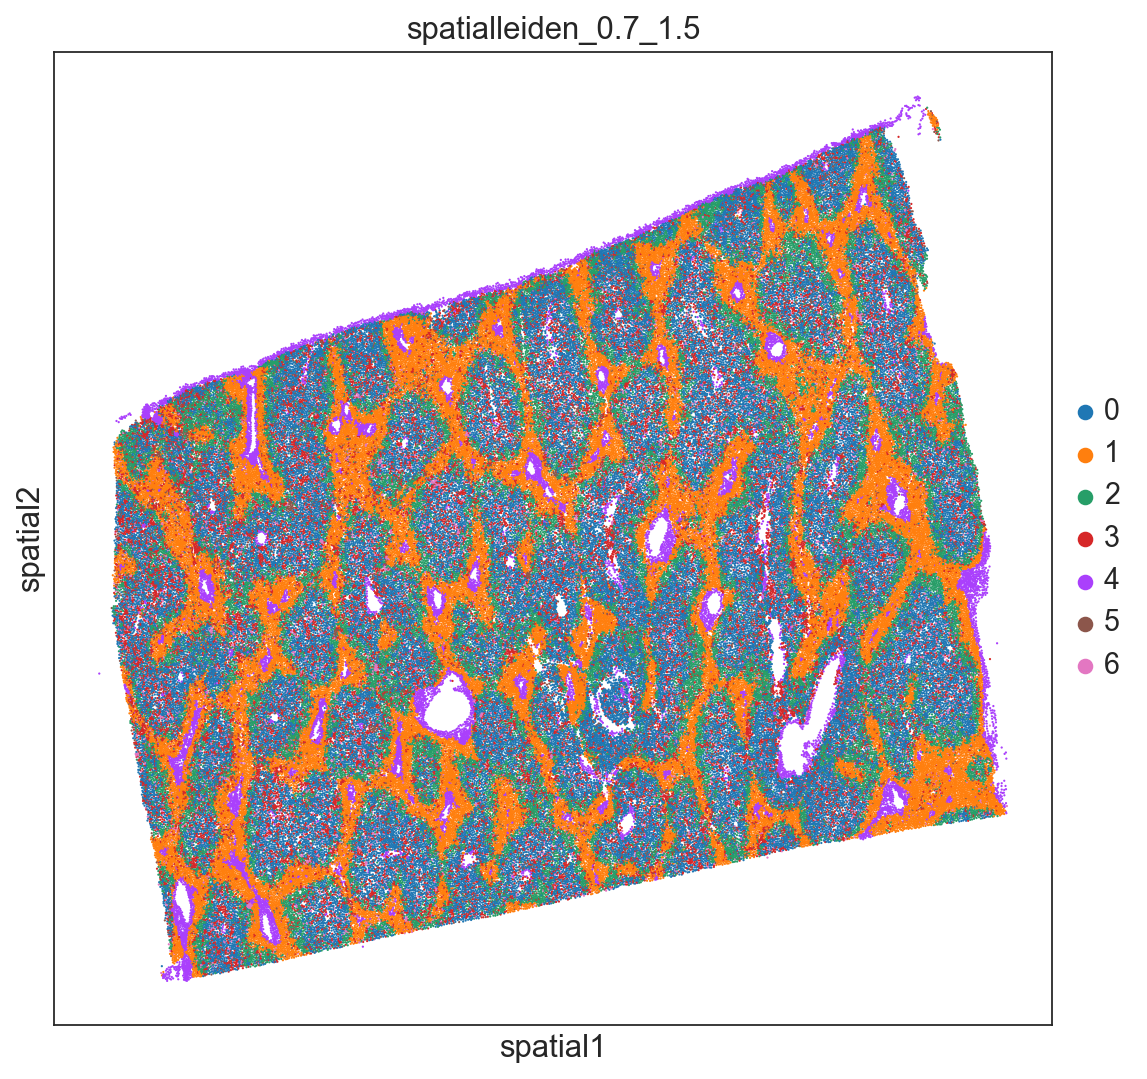

In [ ]:
sc.pl.embedding(adata_temp, basis="spatial", color=["spatialleiden_0.7_1.5"], size = 4)

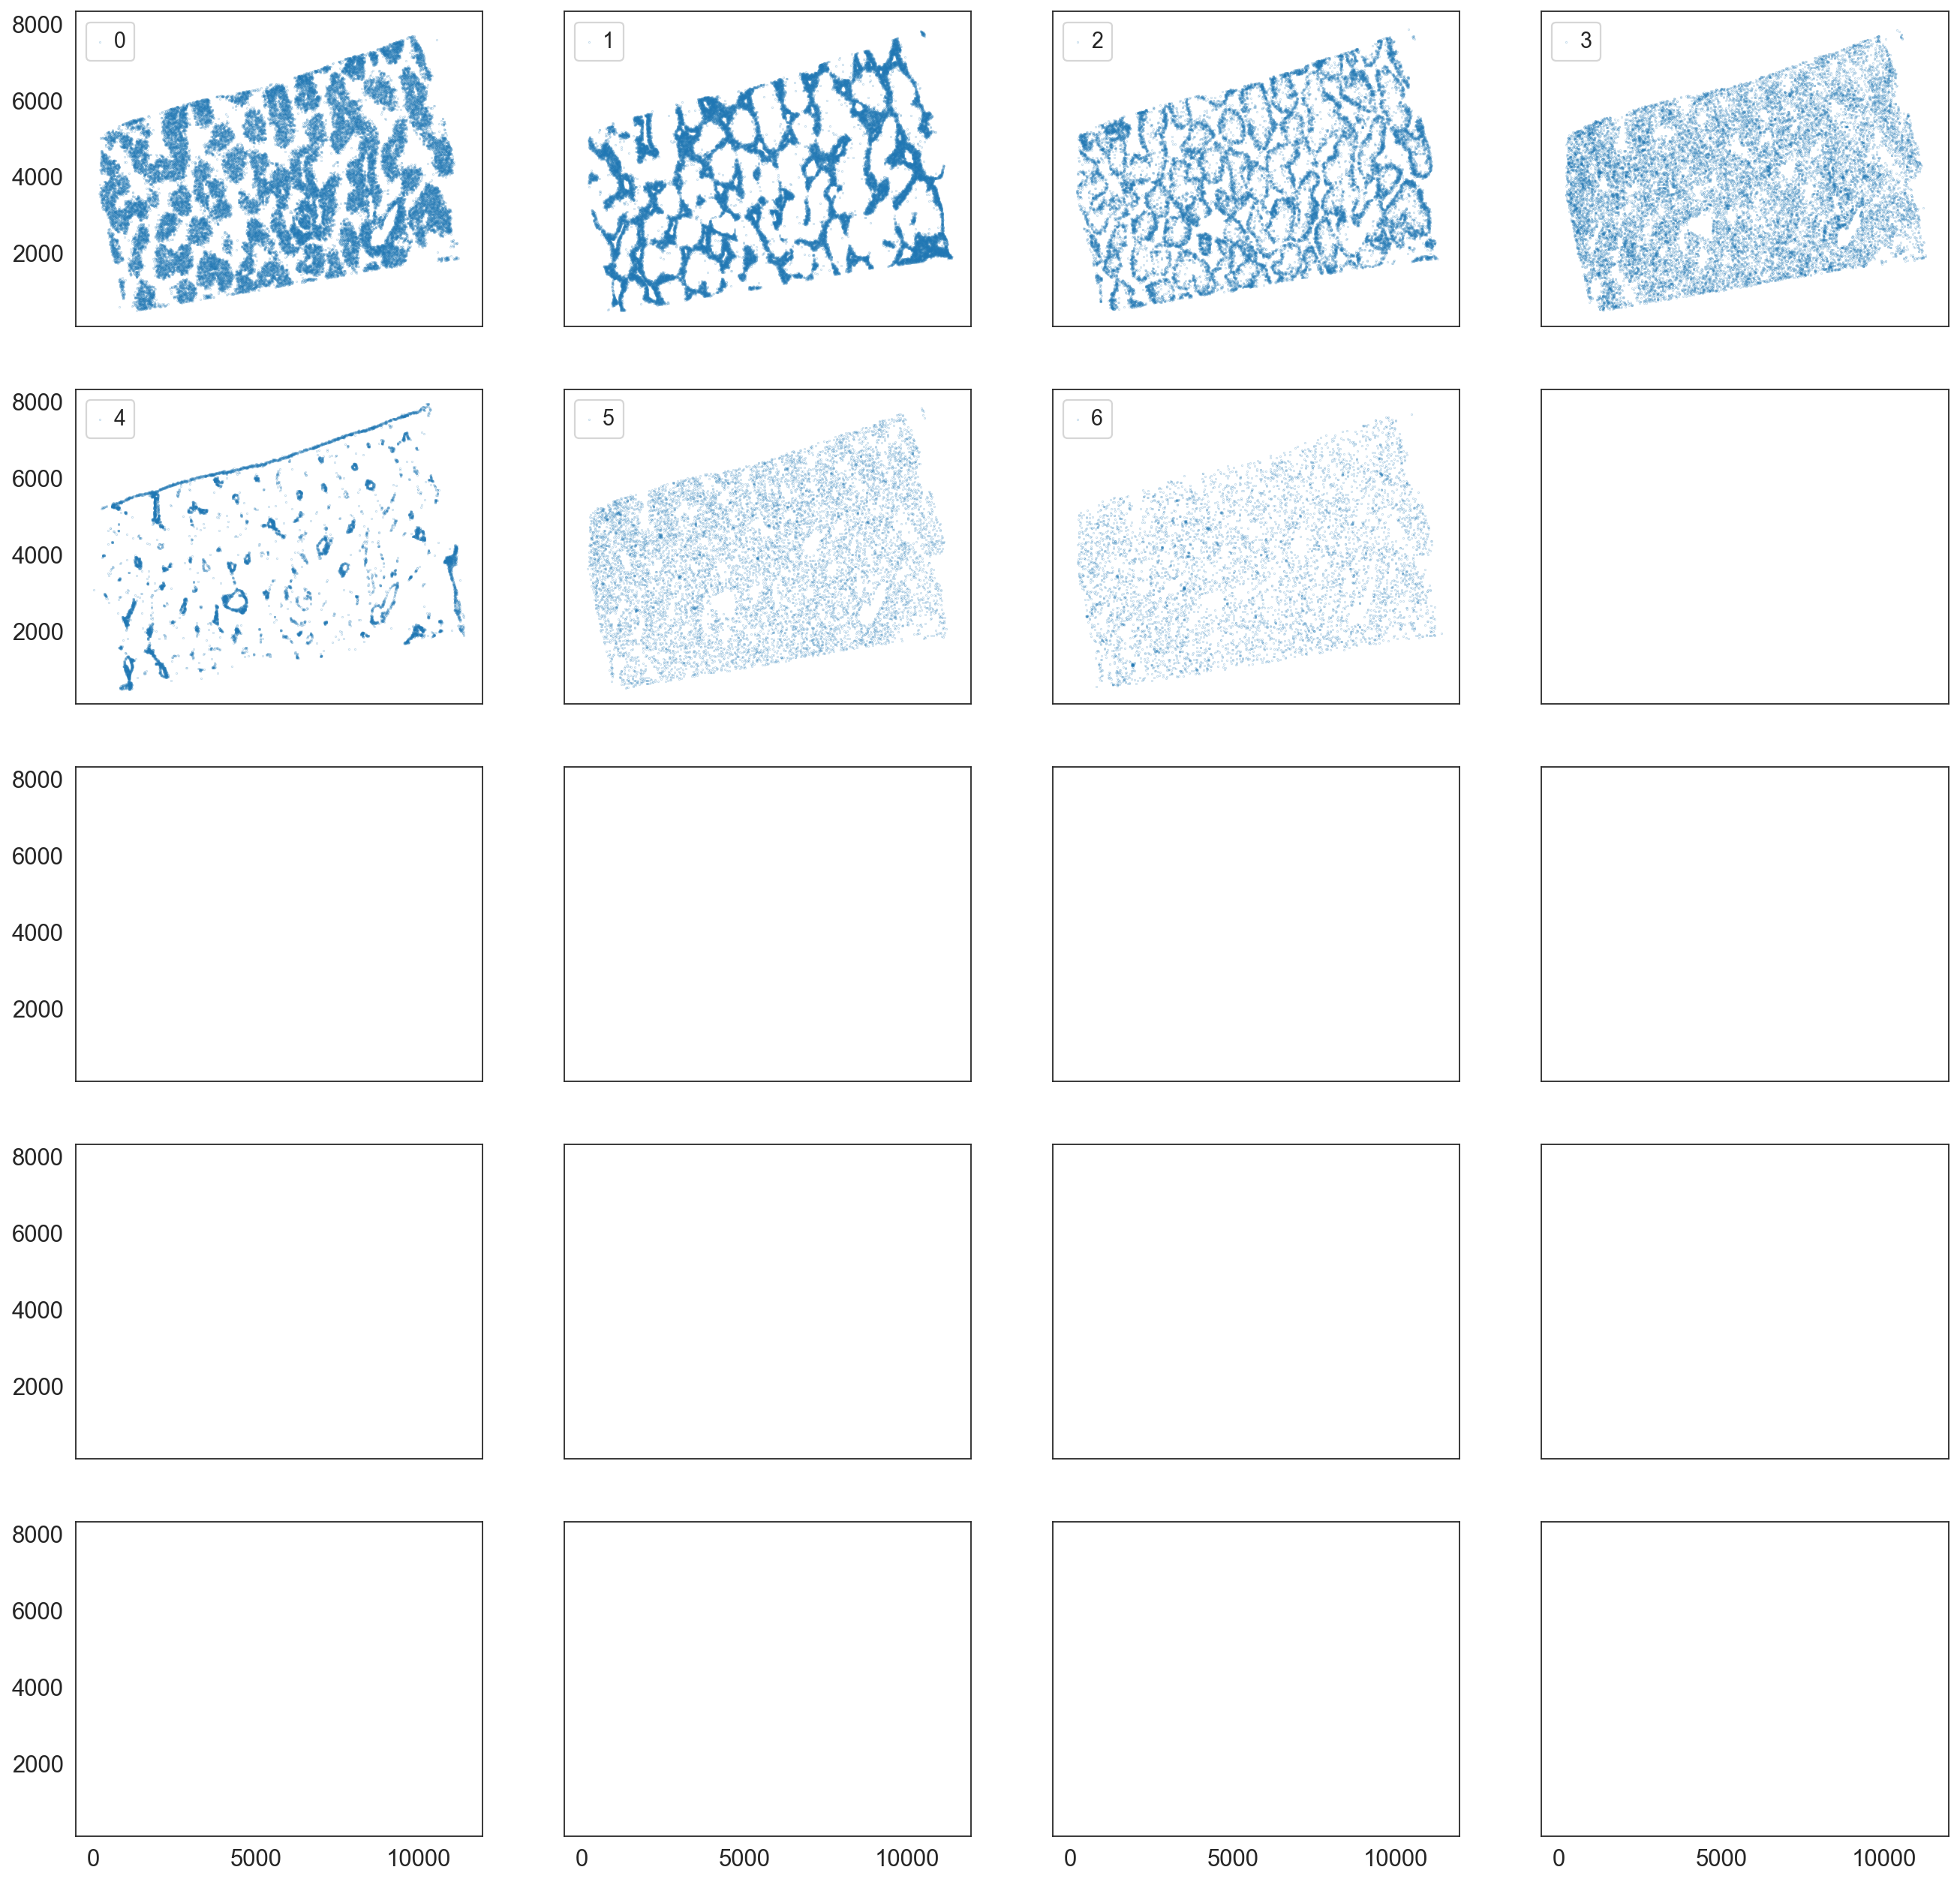

In [ ]:
fig, axs = plt.subplots(5,4, figsize = (20,20), sharex=True, sharey=True)
axs = axs.flatten()

for n in adata_temp.obs['spatialleiden_0.7_1.5'].unique():
    axs[n].scatter(x = adata_temp[adata_temp.obs['spatialleiden_0.7_1.5']==n].obs['x_centroid'], y = adata_temp[adata_temp.obs['spatialleiden_0.7_1.5']==n].obs['y_centroid'], s = 0.01, label = n)
    axs[n].legend()

In [ ]:
temp_dict = {0:"",
             1 : "",
             2: "",
             3: "",
             4: "",
             5: "",
             6: "",
             7:"",
             8:"",
             9:"",
             10:"",
             11 : "",
             12:"",
             13:"",
             14:"",
             15:"",
             }

adata_temp.obs['SL_name'] = adata_temp.obs['spatialleiden_0.7_1.5'].map(temp_dict)
global_dict.update(dict(zip(adata_temp.obs['cell_id'], adata_temp.obs['SL_name'])))


In [ ]:
# sc.tl.leiden(adata, directed=False, random_state=random_state, resolution=0.7)

keys = [
        (1,1),(1,1.2),(1,1.5),(1,1.8),
        (0.7,1),(0.7,1.2),(0.7,1.5),(0.7,1.8),
        (0.4,1),(0.4,1.2),(0.4,1.5),(0.4,1.8),
        (0.4,0.2),(0.4,0.4),(0.4,0.6),(0.4,0.8)
        ]

for a, b in keys:
    sl.spatialleiden(adata, resolution = a,  layer_ratio=b, directed=(False, True), random_state=random_state,
                 key_added= f"spatialleiden_{a}_{b}")


In [ ]:
sc.pl.embedding(adata, basis="spatial", color=["leiden", "spatialleiden"], size = 4)

In [ ]:
sc.pl.embedding(adata, basis="spatial", color=["spatialleiden_0.7_1","spatialleiden_0.7_1.2","spatialleiden_0.7_1.5","spatialleiden_0.7_1.8"], size = 4)

In [ ]:
sc.pl.embedding(adata, basis="spatial", color=["spatialleiden_0.4_1","spatialleiden_0.4_1.2","spatialleiden_0.4_1.5","spatialleiden_0.4_1.8"], size = 4)

In [ ]:
sc.pl.embedding(adata, basis="spatial", color=["spatialleiden_0.4_0.2","spatialleiden_0.4_0.4","spatialleiden_0.4_0.6","spatialleiden_0.4_0.8"], size = 4)

## Multi-samples?

In [ ]:
from spatialleiden import search_resolution

seed = 2012017
n_cluster = adata.obs["sample"].nunique()

resolutions = search_resolution(
    adata,
    n_cluster,
    latent_kwargs={"directed": False, "random_state": seed},
    spatial_kwargs={"directed": False, "layer_ratio": 0.6, "random_state": seed},
)

In [ ]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=2012017)